In [1]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('/content/drive/MyDrive/AI New folder/Algerian_forest_fires_cleaned_dataset.csv')

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [5]:
# Remove unnecessary date-related columns
# axis=1 indicates that we are dropping columns (not rows)
# inplace=True updates the original DataFrame directly

df.drop(columns=["day", "month", "year"], inplace=True)


For this project, our objective is to predict whether a forest fire occurs based on environmental conditions such as temperature, humidity, wind speed, and other weather-related features.

Since the **day**, **month**, and **year** columns are not required for building our prediction model, we remove them to simplify the dataset.

Removing unnecessary features has several advantages:

* Reduces the complexity of the dataset.
* Helps the model focus on meaningful features.
* Can improve training speed.
* Reduces the chances of learning irrelevant patterns (noise).

> **Note:** Date columns are not always useless. In many real-world projects, dates can provide valuable information. For example, we can extract useful features such as:

> * Day of the week
> * Month
> * Season
> * Quarter
> * Weekend or Weekday
> * Holiday information

> This process is called **Date Feature Engineering**. In this notebook, however, these date columns are not required, so we remove them.


In [6]:
# Display the first five rows after removing the columns
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [7]:
# Count the number of samples in each class
print("Class Counts:")
print(df["Classes"].value_counts())

print("\nClass Percentage:")
print((df["Classes"].value_counts(normalize=True) * 100).round(2))

Class Counts:
Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

Class Percentage:
Classes
fire             53.91
not fire         41.56
fire              1.65
fire              0.82
not fire          0.82
not fire          0.41
not fire          0.41
not fire          0.41
Name: proportion, dtype: float64


This means:

* There are **137 observations** where a forest fire occurred.
* There are **106 observations** where no forest fire occurred.


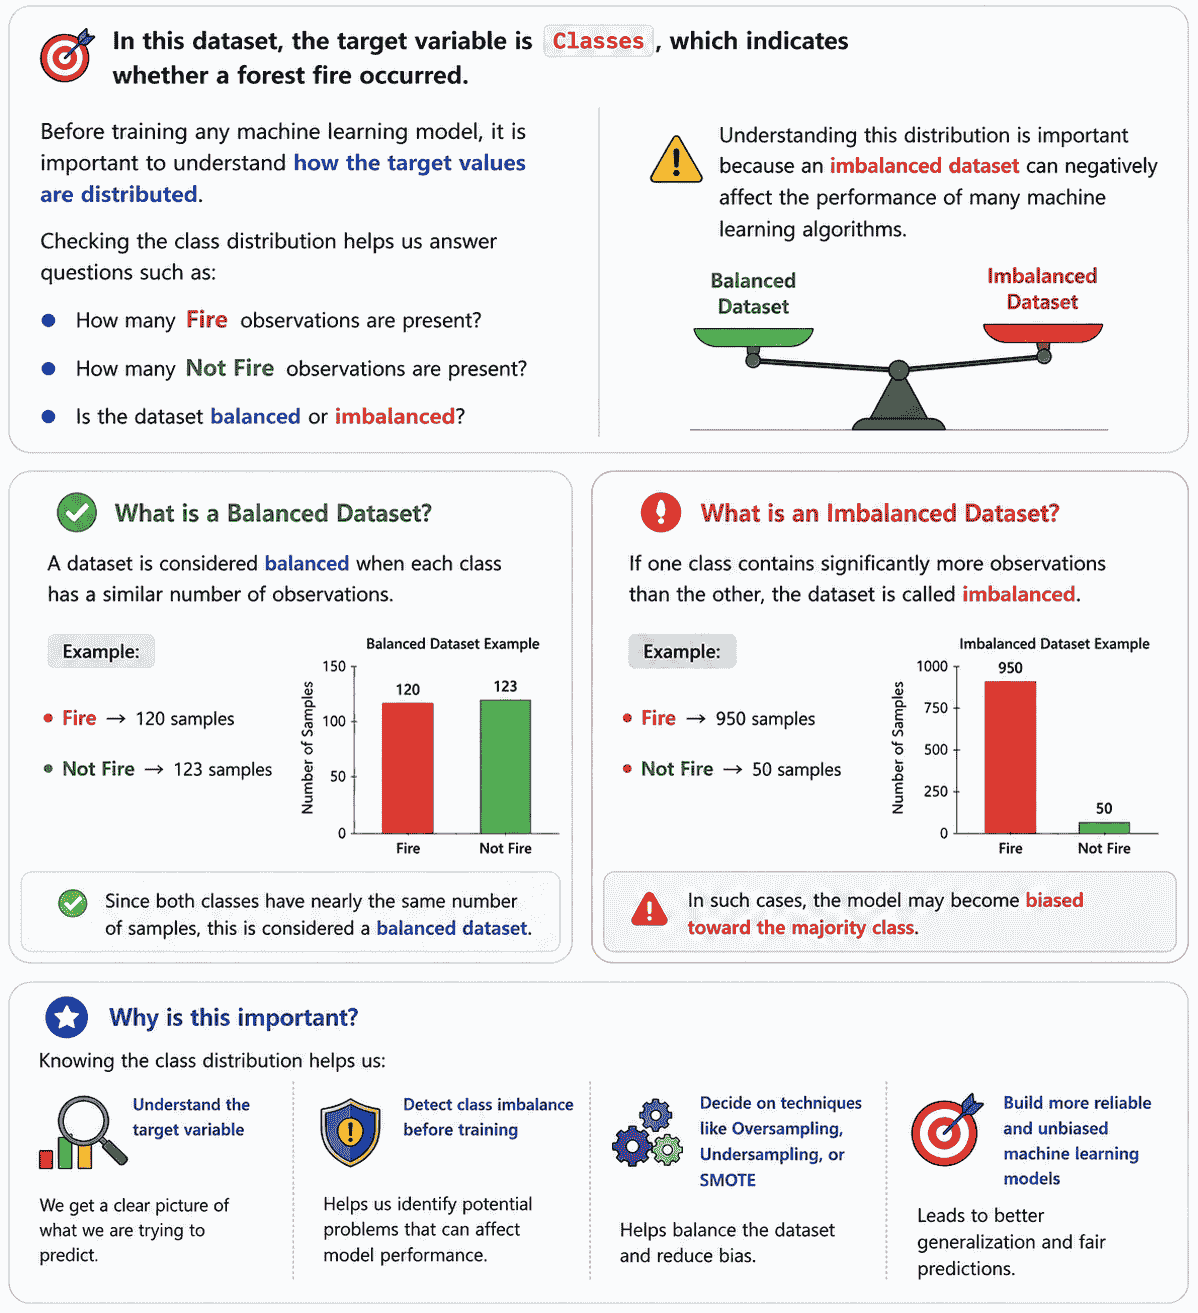

# **Encode the Target Variable**

The **`Classes`** column is our **target variable**, and it currently contains **categorical (text)** values:

* `Fire`
* `Not Fire`

However, most machine learning algorithms can only work with **numerical data**. They cannot directly process text values.

Therefore, before training our model, we need to convert these categorical labels into numerical values. This process is known as **Label Encoding**.

In this notebook, we use the following mapping:

| Original Value | Encoded Value |
| -------------- | ------------: |
| Not Fire       |             0 |
| Fire           |             1 |

This conversion makes the target variable suitable for machine learning algorithms while preserving the meaning of each class.

In [8]:
# Convert the target labels into numerical values
# "Not Fire" → 0
# "Fire" → 1
# Convert labels to lowercase and remove extra spaces before encoding
df["Classes"] = np.where(
    df["Classes"].str.strip().str.lower() == "not fire",
    0,
    1
)

In [9]:
# Display the unique values after encoding
df["Classes"].unique()

array([0, 1])

**Expected Output**

```python
array([1, 0])
```

or

```python
array([0, 1])
```

The order may vary depending on how the values appear in the dataset, but both outputs are correct.

In [10]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [11]:
# Count the occurrences of each encoded class
df["Classes"].value_counts()

,count
Classes,
1,137
0,106


**Divide Dataset into Independent and Dependent Features**

In [12]:
# Create the feature matrix (Independent Features)
# Drop the target column because it is what we want to predict
X = df.drop(columns=["FWI"])

# Create the target variable (Dependent Feature)
y = df["FWI"]

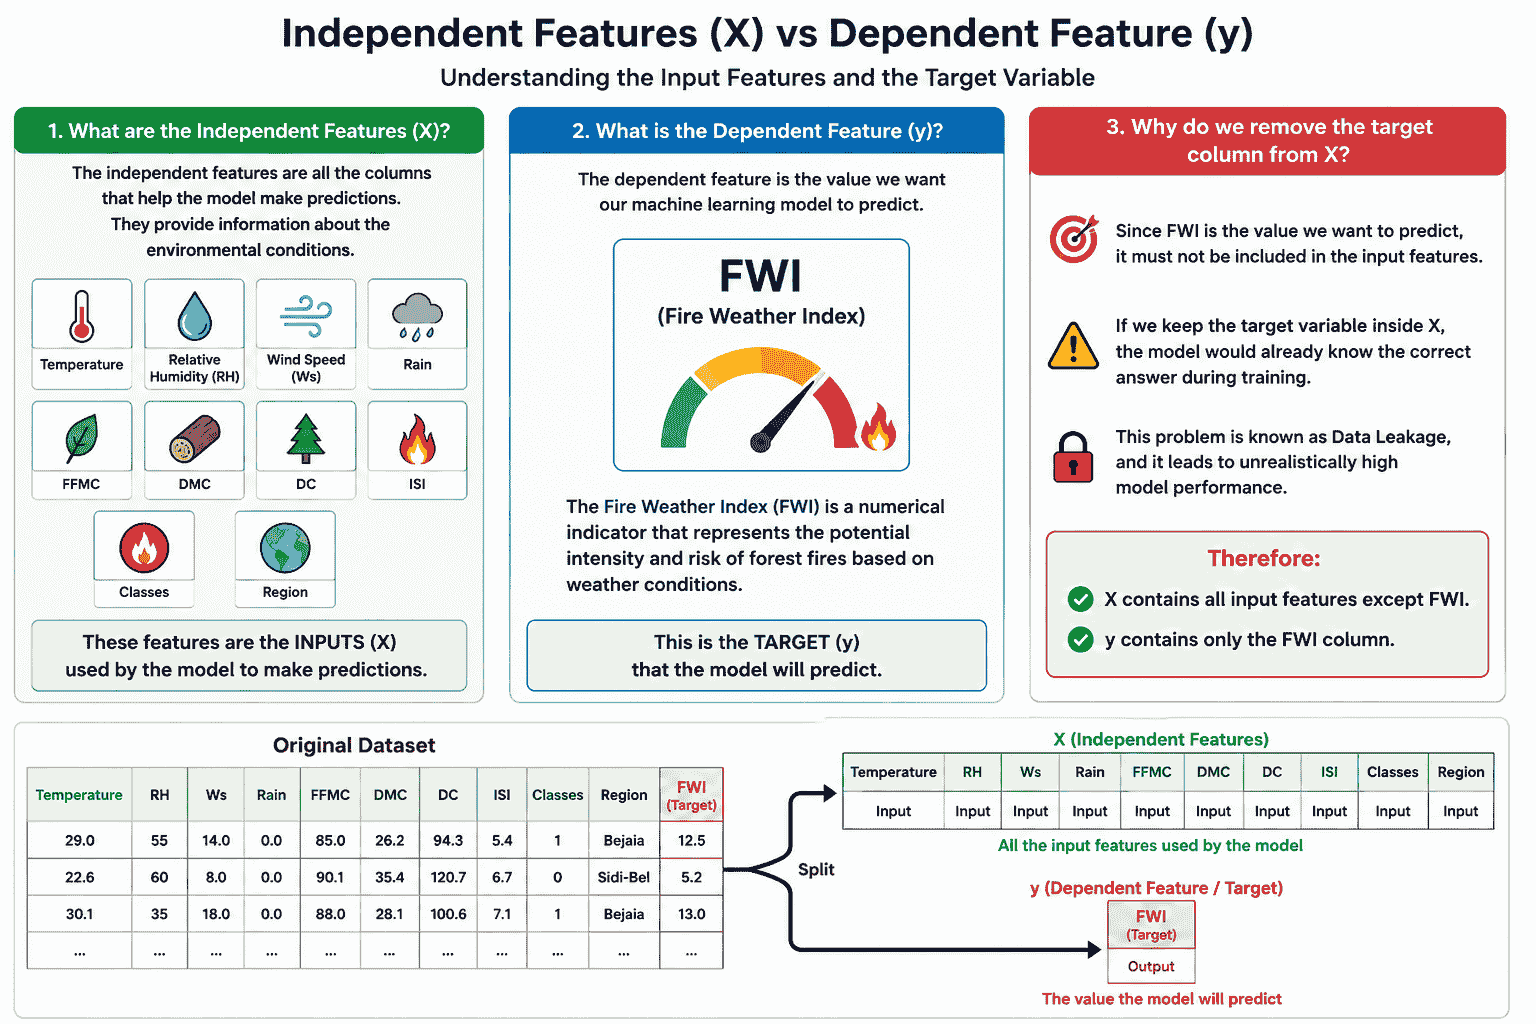

In [13]:
print("Independent Features (X):")
display(X.head())

print("\nDependent Feature (y):")
display(y.head())

Independent Features (X):


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0



Dependent Feature (y):


,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5


## **Split the Dataset into Training and Testing Sets**

In [14]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 75% -> Training data
# 25% -> Testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [15]:
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test shape  : {y_test.shape}")

X_train shape : (182, 11)
X_test shape  : (61, 11)
y_train shape : (182,)
y_test shape  : (61,)


## **Feature Selection Based on Correlation**

**Why do we calculate the correlation matrix?**

In machine learning, it is common for some features to carry **similar or overlapping information**.

For example, if two features are almost identical, keeping both of them may not provide any additional benefit to the model. Instead, it can increase model complexity and introduce a problem called **multicollinearity**.

To identify such relationships, we calculate the **correlation matrix**.

A correlation matrix helps us understand **how strongly each feature is related to every other feature**.

 **What is Correlation?**

**Correlation** is a statistical measure that indicates the **strength and direction of the relationship between two variables**.

The correlation coefficient always lies between **-1** and **+1**.

| Correlation Value | Meaning                      |
| ----------------: | ---------------------------- |
|            **+1** | Perfect Positive Correlation |
|             **0** | No Correlation               |
|            **-1** | Perfect Negative Correlation |


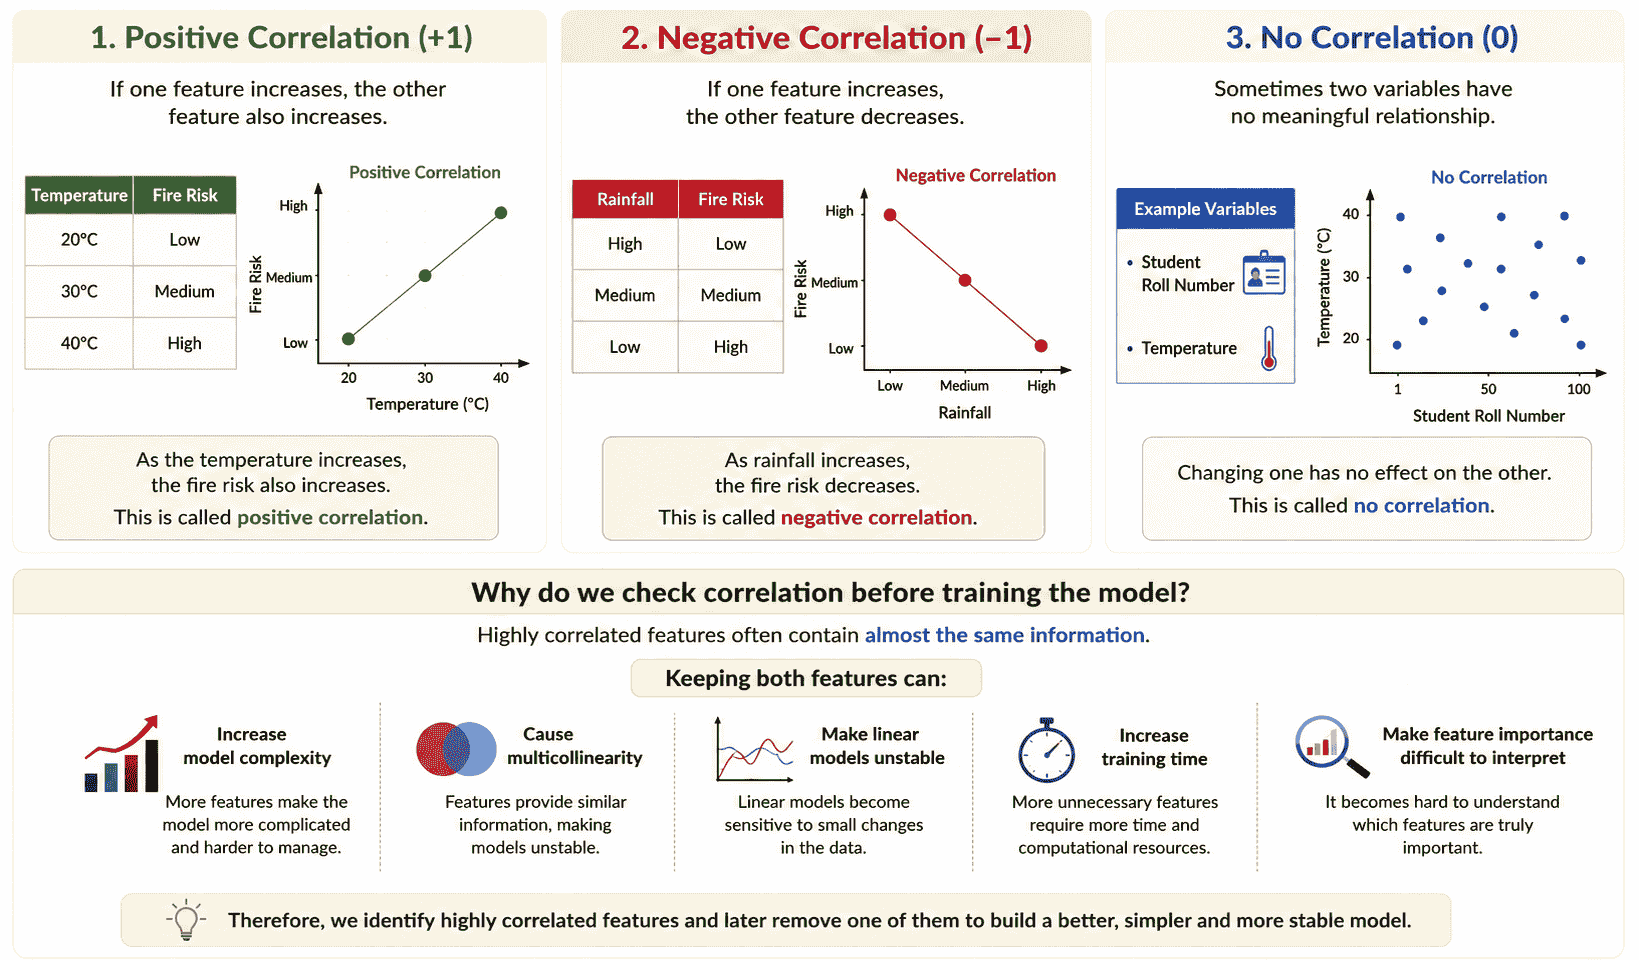

In [16]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


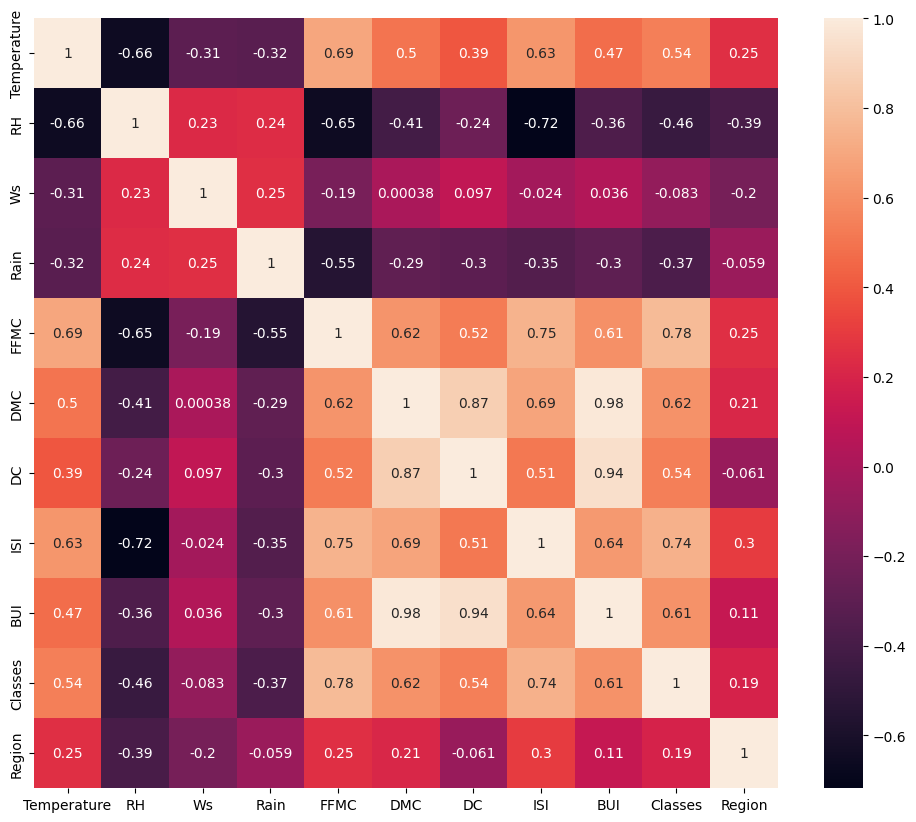

In [17]:
import seaborn as sns
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr, annot=True)
plt.show()

From the correlation heatmap, we observe that some feature pairs—particularly **DMC, DC, and BUI** —are highly correlated (correlation > 0.85). Such strong relationships indicate multicollinearity, where multiple features provide nearly the same information. In the next step, we will apply a correlation threshold (e.g., 0.85) to identify and remove redundant features, resulting in a simpler, more stable, and easier-to-interpret machine learning model.

# **Detect and Remove Multicollinearity Using Correlation**




## **What is Multicollinearity?**

**Multicollinearity** occurs when two or more independent features are **highly correlated** with each other.

In simple terms, it means that multiple features provide **almost the same information** to the machine learning model.

For example:

Suppose we have two features:

* **Height (in cm)**
* **Height (in inches)**

Both represent the same information using different units.

Keeping both columns doesn't provide any additional knowledge to the model.

Similarly, in our dataset, some weather-related features are highly correlated and contain overlapping information.

---

**Why is Multicollinearity a Problem?**

Highly correlated features can negatively affect some machine learning algorithms, especially linear models.

Some common problems include:

* The model becomes unnecessarily complex.
* It becomes difficult to determine which feature is actually important.
* Linear Regression coefficients become unstable.
* Small changes in the dataset can produce large changes in model coefficients.
* Training may become slower.

To avoid these issues, we remove one feature from every highly correlated pair.

**How do we detect Multicollinearity?**

Earlier, we calculated the **correlation matrix**.

Now, we'll use that matrix to identify features whose correlation exceeds a predefined threshold.

If two features have a correlation greater than the threshold, we keep one feature and remove the other.

**What is the Correlation Threshold?**

The threshold determines when two features are considered **too similar**.

In this notebook, we use:

```text
Threshold = 0.85
```

This means:

* Correlation > **0.85** → Remove one of the features.
* Correlation ≤ **0.85** → Keep both features.

> **Note:** There is no universal threshold. Common values include **0.80**, **0.85**, **0.90**, or **0.95**, depending on the problem and domain knowledge.


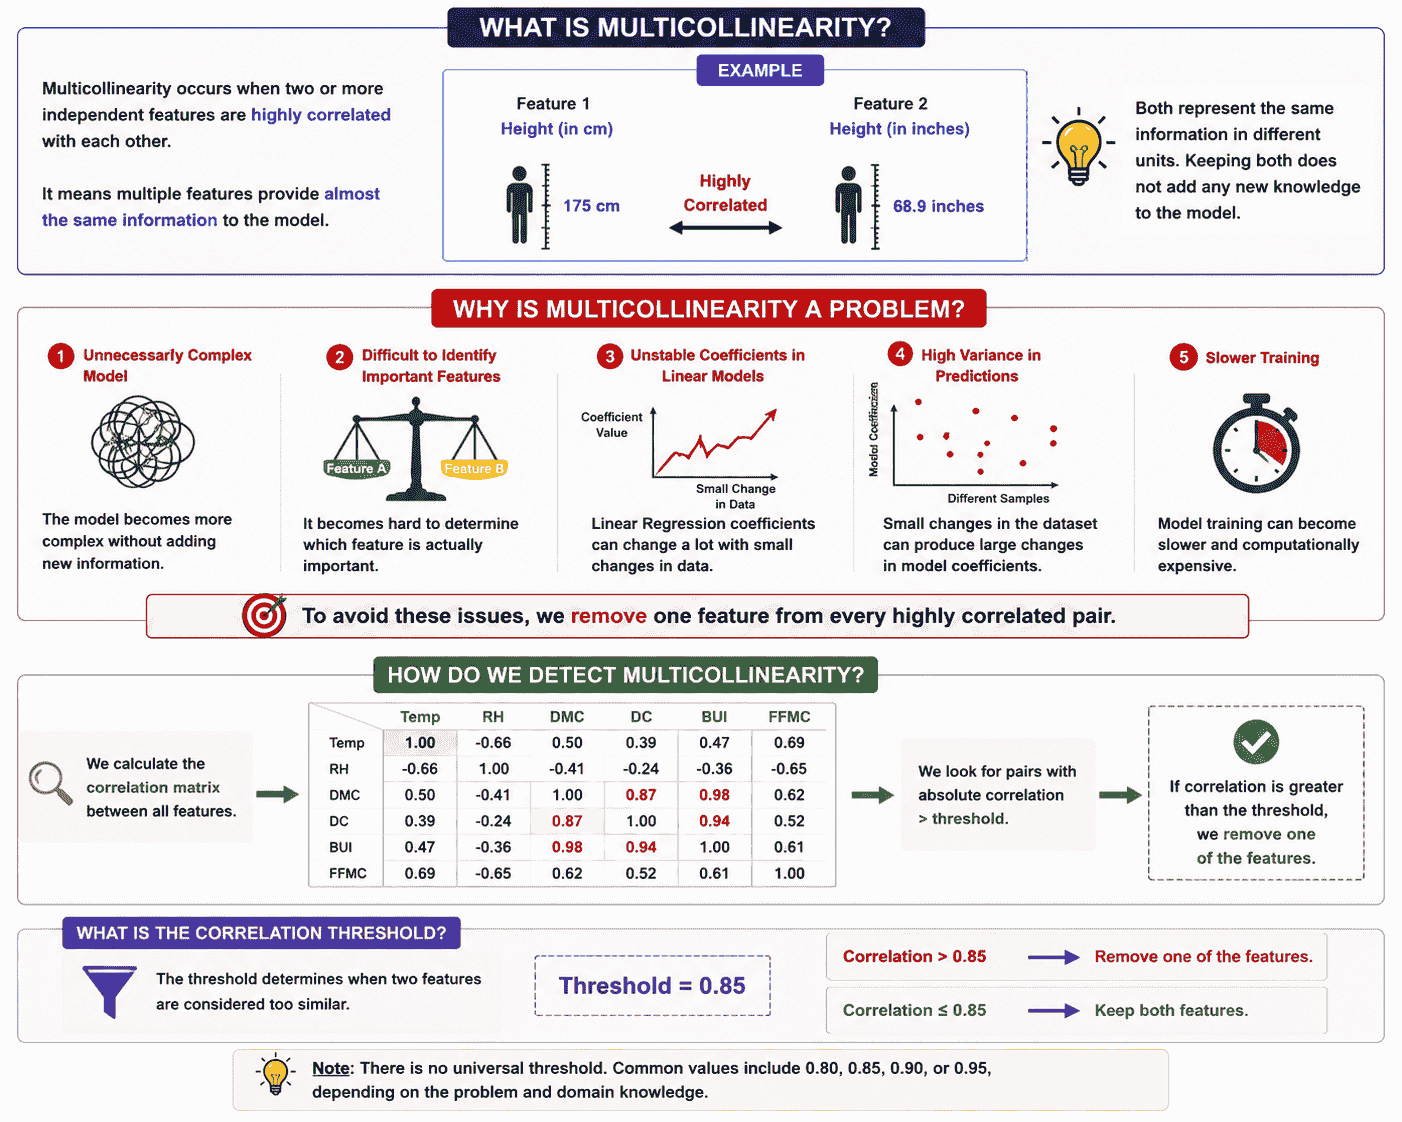

In [18]:
# Function to identify highly correlated features
def correlation(dataset, threshold):
    """
    Returns a set of feature names whose absolute
    correlation is greater than the specified threshold.
    """

    # Store features to remove
    col_corr = set()

    # Calculate correlation matrix
    corr_matrix = dataset.corr()

    # Compare every pair of features
    for i in range(len(corr_matrix.columns)):
        for j in range(i):

            # Check absolute correlation value
            if abs(corr_matrix.iloc[i, j]) > threshold:

                # Store the feature name
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    return col_corr

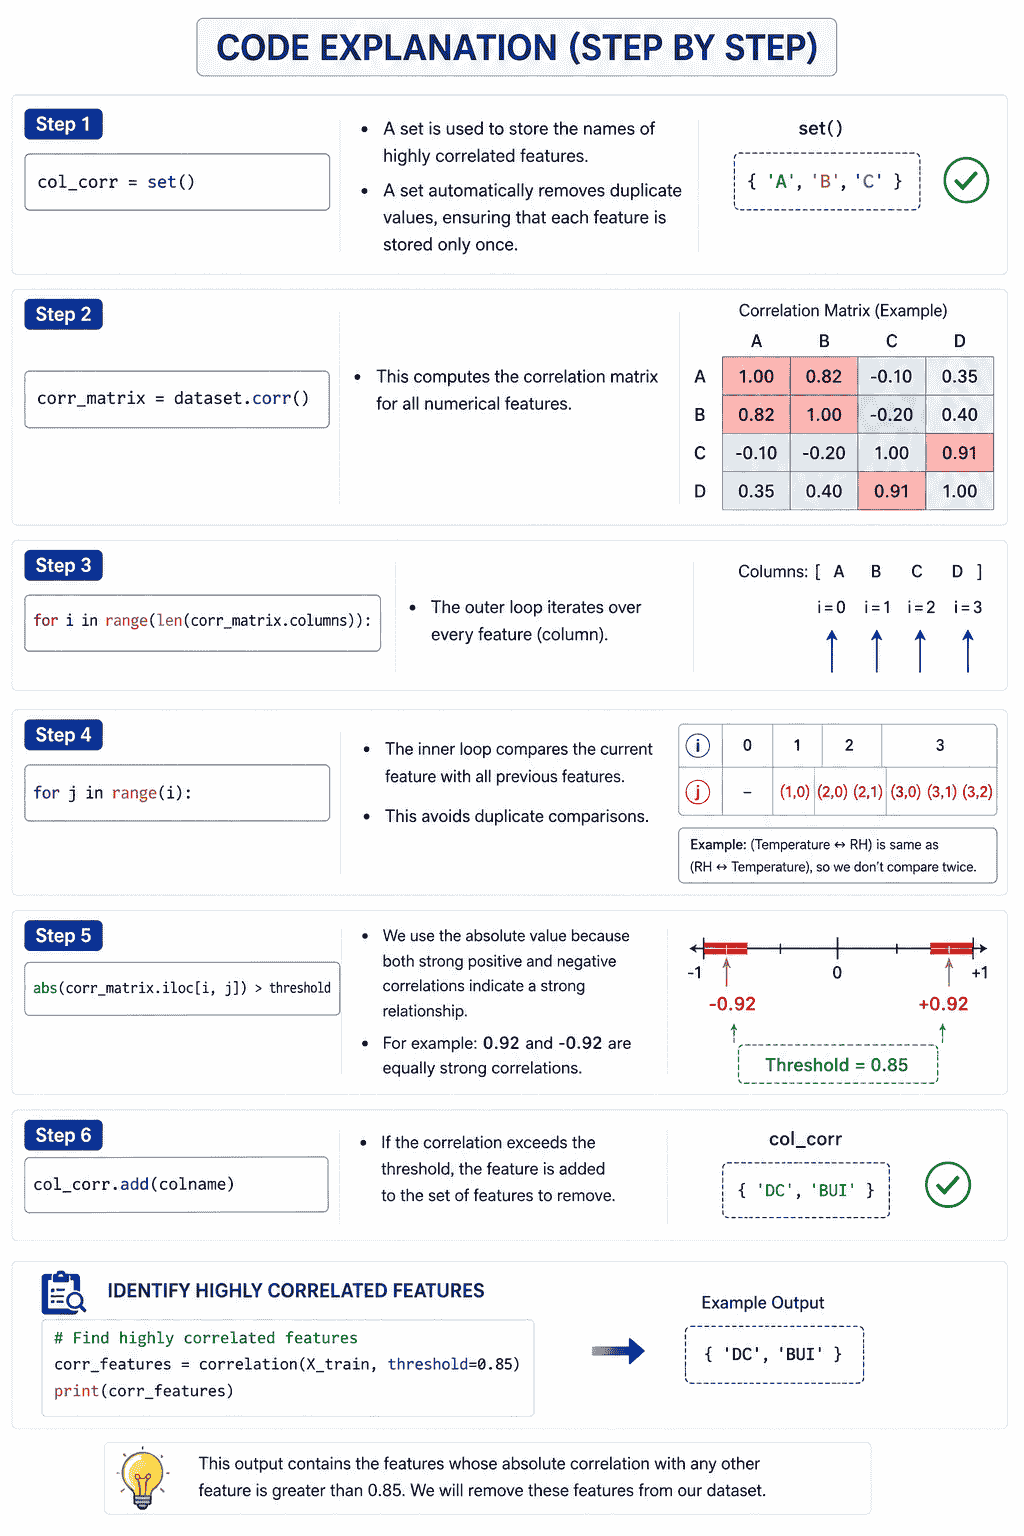

In [19]:
# Find highly correlated features
corr_features = correlation(X_train, threshold=0.85)

print(corr_features)

{'DC', 'BUI'}


This means:

* **DC** has a correlation greater than **0.85** with another feature.
* **BUI** also has a correlation greater than **0.85** with another feature.

These features carry redundant information and can be removed.

**Note:** The exact output may vary depending on the dataset and the chosen threshold.

In [20]:
# Remove highly correlated features from both datasets

X_train = X_train.drop(columns=corr_features)
X_test = X_test.drop(columns=corr_features)

**Why don't we use `inplace=True`?**

Assigning the result back to `X_train` and `X_test` is generally considered cleaner and avoids potential issues with chained assignments in pandas.


In [21]:
# X_train.drop(corr_features, axis=1, inplace=True)
# X_test.drop(corr_features, axis=1, inplace=True)

In [22]:
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape: (182, 9)
Testing Data Shape : (61, 9)


**Faeture Scaling or Standardization**

In [23]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Learn scaling parameters from the training data
# and transform the training features
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same parameters
X_test_scaled = scaler.transform(X_test)

In [24]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]])

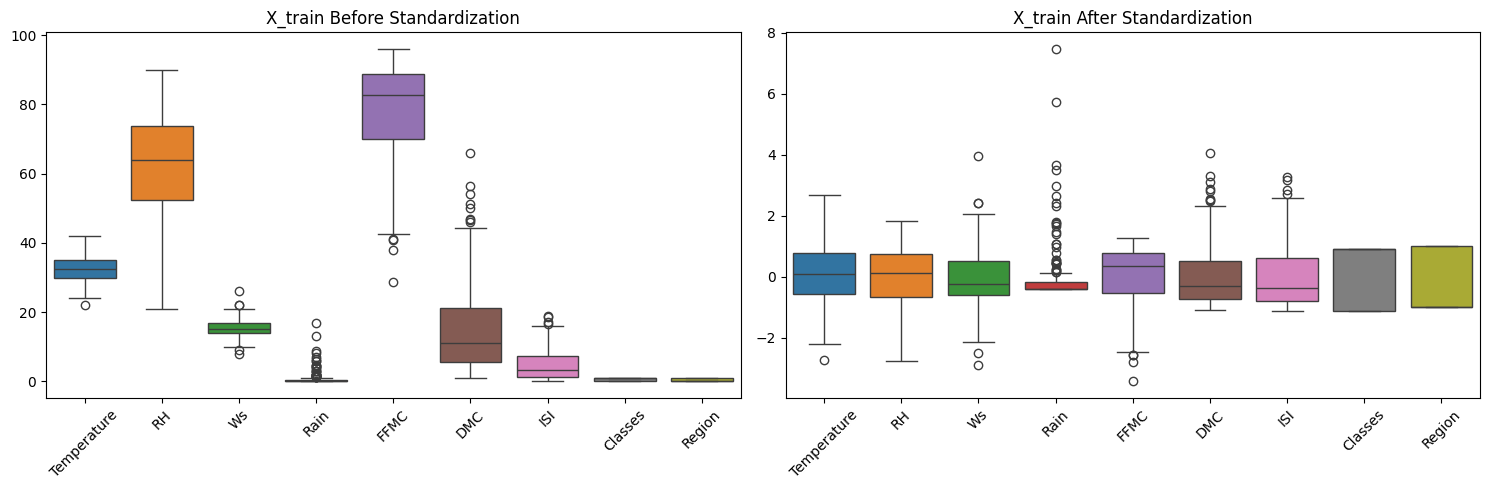

In [25]:
# Create box plots to compare feature distributions
plt.figure(figsize=(15, 5))

# Before scaling
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title("X_train Before Standardization")
plt.xticks(rotation=45)

# After scaling
plt.subplot(1, 2, 2)
sns.boxplot(
    data=pd.DataFrame(
        X_train_scaled,
        columns=X_train.columns
    )
)
plt.title("X_train After Standardization")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **Observations from the Box Plots**

**Before Standardization**

You will notice that:

* Different features have very different ranges.
* Some features span a much wider range than others.
* Larger-scale features dominate the visualization.
* Comparing features directly is difficult.

For example:

* **Rain** has relatively small values.
* **DMC** and **BUI** have much larger values.

---

**After Standardization**

After applying the Standard Scaler:

* All features are centered around **0**.
* The spread of each feature becomes more comparable.
* Features are now on a similar scale.
* No single feature dominates because of its larger numerical values.

> **Important**: Standardization does not remove outliers. It only changes the scale of the features.

# **Linear Regression Model**

**Why are we using Linear Regression?**

Our target variable **FWI** is continuous.

Linear Regression is a good baseline model because:

* It is simple and easy to interpret.
* It trains quickly.
* It provides interpretable coefficients.
* It works well when there is a roughly linear relationship between the features and the target.

---

**Training Workflow**

The training process consists of four main steps:

1. Import the required libraries.
2. Train the Linear Regression model using the training data.
3. Predict the target values for the testing data.
4. Evaluate the model using regression evaluation metrics.

In [26]:
# Import the Linear Regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Initialize the Linear Regression model
linreg = LinearRegression()

In [29]:
# Train the model using the training data
linreg.fit(X_train_scaled, y_train)

LinearRegression()


**`StandardScaler` transforms data, so it has `fit()`, `transform()`, and `fit_transform()`.**

**`LinearRegression` learns a model, so it has `fit()` and `predict()`, but it does not transform the data.**


**Two Types of Objects in Scikit-learn**

| Type                  | Purpose              | Examples                                                         |
| --------------------- | -------------------- | ---------------------------------------------------------------- |
| **Transformer**       | Changes the data     | StandardScaler, MinMaxScaler, OneHotEncoder, PCA                 |
| **Estimator (Model)** | Learns from the data | LinearRegression, DecisionTree, RandomForest, LogisticRegression |


In [30]:
# Predict the target values for the testing data
y_pred = linreg.predict(X_test_scaled)

**Evaluate the Model**

After training, we need to check how well the model performs on unseen data.

We'll use three commonly used regression metrics:

* Mean Absolute Error (MAE)
* Mean Squared Error (MSE)
* R² Score

In [31]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae:.3f}")
print(f"Mean Squared Error  : {mse:.3f}")
print(f"R² Score            : {r2:.3f}")

Mean Absolute Error : 0.547
Mean Squared Error  : 0.674
R² Score            : 0.985


This means:

**Mean Absolute Error (MAE)**

On average, the model's prediction differs from the actual Fire Weather Index by about **0.55 units**.

Lower MAE indicates better performance.

---

**Mean Squared Error (MSE)**

MSE measures the average squared prediction error.

Large errors receive a larger penalty because the errors are squared.

Lower MSE indicates better performance.

---

**R² Score**

The R² Score indicates how well the model explains the variation in the target variable.

Interpretation:

|    R² Score | Meaning                                 |
| ----------: | --------------------------------------- |
|         1.0 | Perfect prediction                      |
|        0.9+ | Excellent model                         |
|  Around 0.7 | Good model                              |
|  Around 0.5 | Moderate model                          |
|           0 | No improvement over predicting the mean |
| Less than 0 | Poor model                              |

An R² Score close to **1** indicates that the model fits the data very well.

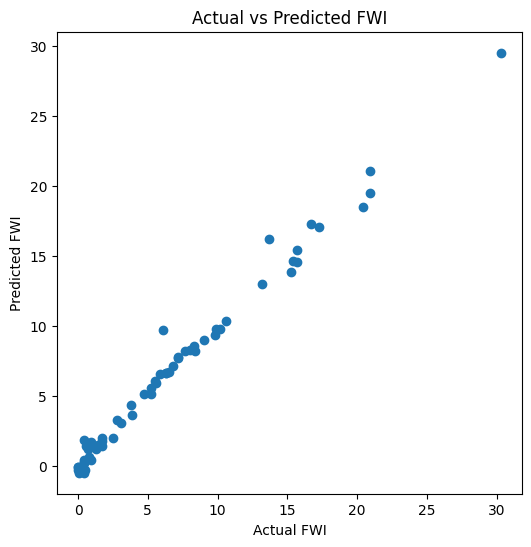

In [32]:
# Compare actual values with predicted values
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI")

plt.show()

Each dot represents one testing sample.

**Good Model**

If most points lie close to an imaginary diagonal line,

it means

> Actual Value ≈ Predicted Value

This indicates good model performance.

---

**Poor Model**

If the points are widely scattered,

it means the model's predictions differ significantly from the actual values.

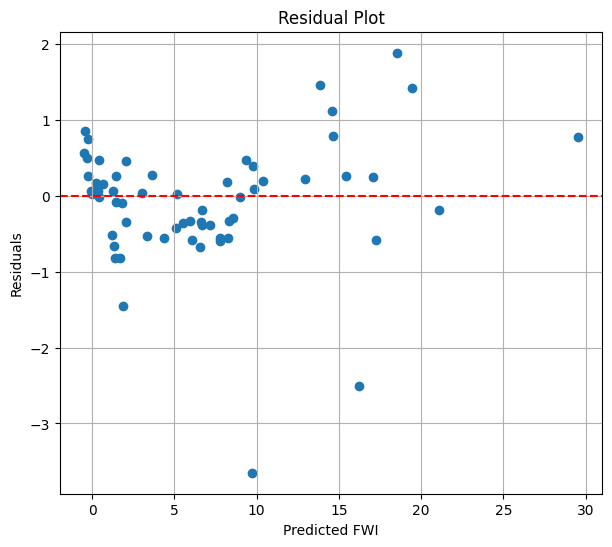

In [33]:
residuals = y_test - y_pred

plt.figure(figsize=(7,6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted FWI")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

## **Train Lasso Regression**

Lasso (**Least Absolute Shrinkage and Selection Operator**) is an extension of Linear Regression that introduces **L1 Regularization**.

The objective of Lasso Regression is to:

* Reduce overfitting.
* Prevent the model from becoming too complex.
* Automatically remove less important features.

Unlike Linear Regression, Lasso can shrink some coefficients **exactly to zero**, effectively performing **feature selection**.

---

**Why do we need Lasso Regression?**

Suppose a dataset contains many features, but only a few actually contribute to predicting the target variable.

Linear Regression keeps every feature.

Lasso Regression automatically identifies less useful features and reduces their coefficients to zero.

This results in:

* Simpler models.
* Better generalization.
* Reduced overfitting.
* Automatic feature selection.

In [34]:
from sklearn.linear_model import Lasso

# Initialize the Lasso Regression model
lasso = Lasso()

# Train the model
lasso.fit(X_train_scaled, y_train)

# Predict on the testing data
lasso_pred = lasso.predict(X_test_scaled)


### **Evaluate the Lasso Model**

In [35]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, lasso_pred)
mse = mean_squared_error(y_test, lasso_pred)
r2 = r2_score(y_test, lasso_pred)

print(f"Mean Absolute Error : {mae:.3f}")
print(f"Mean Squared Error  : {mse:.3f}")
print(f"R² Score            : {r2:.3f}")

Mean Absolute Error : 1.133
Mean Squared Error  : 2.248
R² Score            : 0.949


The evaluation metrics indicate how accurately the Lasso model predicts the Fire Weather Index.

* **Lower MAE** indicates smaller prediction errors.
* **Lower MSE** indicates fewer large errors.
* **Higher R² Score** indicates that the model explains more of the variability in the target variable.

These metrics can be directly compared with those of the Linear Regression model to determine which performs better.

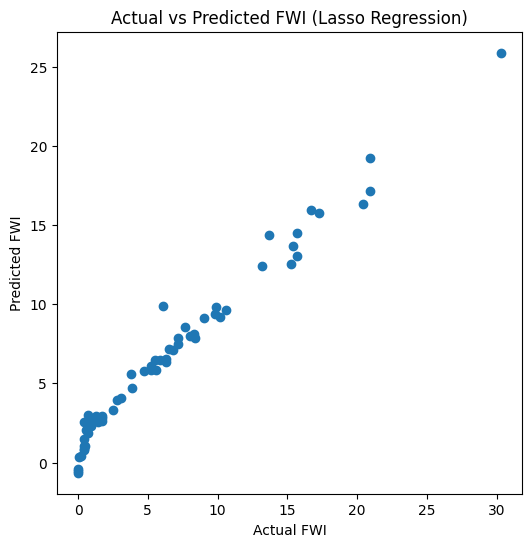

In [36]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, lasso_pred)

plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (Lasso Regression)")

plt.show()


When analyzing the scatter plot:

* Points close to the imaginary diagonal line indicate accurate predictions.
* Widely scattered points indicate larger prediction errors.
* Compare this plot with the Linear Regression plot to visually assess which model produces predictions closer to the actual values.


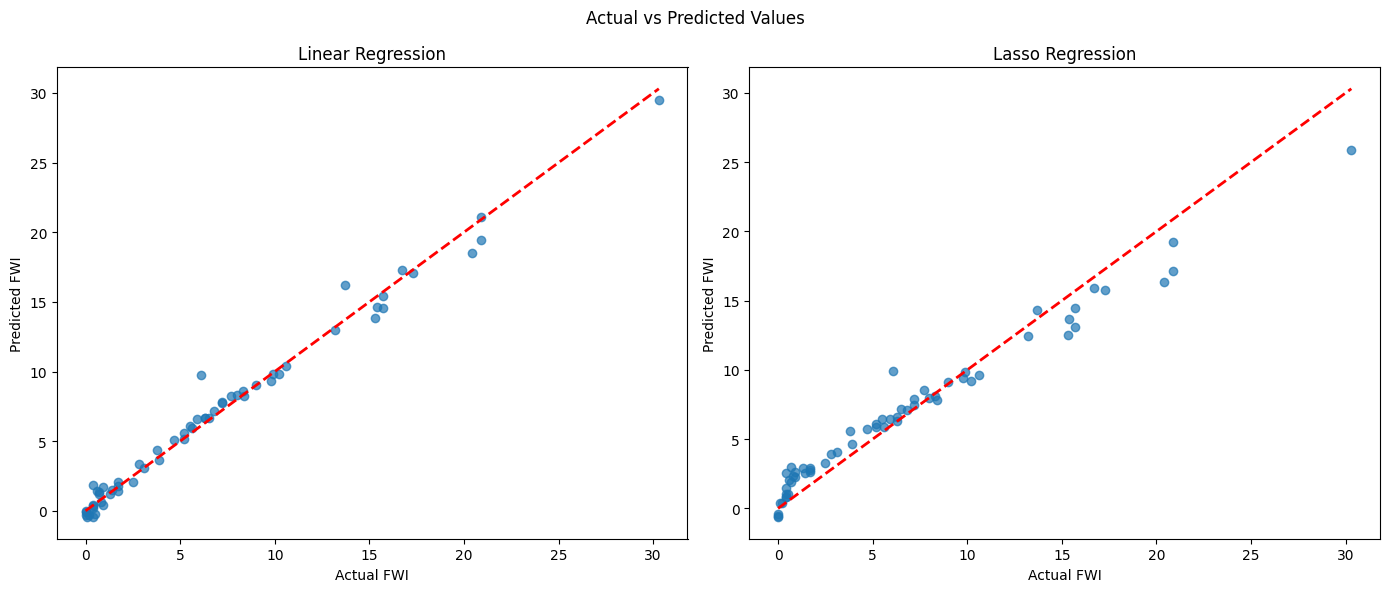

In [37]:
# Predictions
linear_pred = linreg.predict(X_test_scaled)
lasso_pred = lasso.predict(X_test_scaled)

# Create side-by-side comparison
plt.figure(figsize=(14, 6))

# Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, linear_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Linear Regression")

# Lasso Regression
plt.subplot(1, 2, 2)
plt.scatter(y_test, lasso_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Lasso Regression")

plt.suptitle("Actual vs Predicted Values")
plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso Regression"],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    "R2 Score": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, lasso_pred)
    ]
})

display(results)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.546824,0.821144,0.984766
1,Lasso Regression,1.133176,1.499449,0.949202


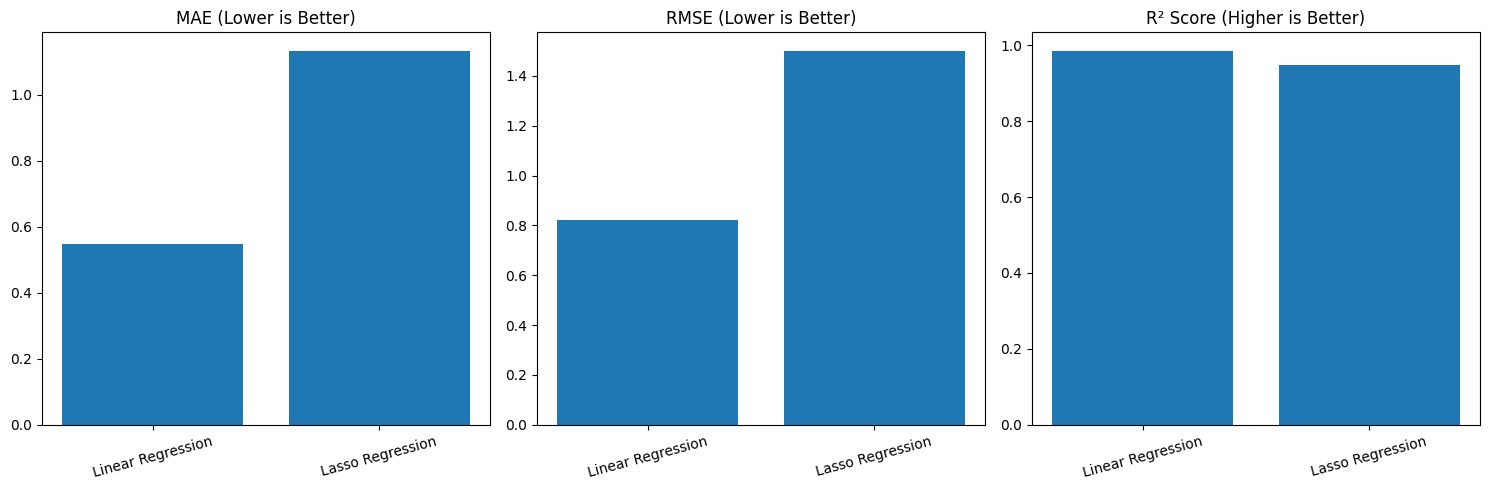

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].bar(results["Model"], results["MAE"])
axes[0].set_title("MAE (Lower is Better)")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results["Model"], results["RMSE"])
axes[1].set_title("RMSE (Lower is Better)")
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(results["Model"], results["R2 Score"])
axes[2].set_title("R² Score (Higher is Better)")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## **Train a Ridge Regression Model**

**Ridge Regression** is an improved version of **Linear Regression** that helps reduce **overfitting** by adding a penalty to large coefficient values.

It uses **L2 Regularization**, which discourages the model from assigning excessively large weights to features.

Unlike Linear Regression, Ridge Regression produces a model that is often more stable and better at generalizing to unseen data.

**How does Ridge Regression work?**

Ridge Regression modifies the Linear Regression cost function by adding an **L2 penalty**.

The optimization objective becomes:

> **Cost Function = Linear Regression Loss + L2 Penalty**

Instead of removing features, Ridge Regression **shrinks** their coefficients toward zero.

**Important:** Ridge Regression **does not make coefficients exactly zero**.

This means:

* Every feature remains in the model.
* Less important features receive smaller weights.
* Important features retain relatively larger weights.

In [40]:
from sklearn.linear_model import Ridge

# Initialize the Ridge Regression model
ridge = Ridge()

# Train the model using the training data
ridge.fit(X_train_scaled, y_train)

# Predict the target values for the testing data
ridge_pred = ridge.predict(X_test_scaled)

In [41]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, ridge_pred)
mse = mean_squared_error(y_test, ridge_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, ridge_pred)

print(f"Mean Absolute Error : {mae:.3f}")
print(f"Mean Squared Error  : {mse:.3f}")
print(f"Root Mean Squared Error : {rmse:.3f}")
print(f"R² Score            : {r2:.3f}")

Mean Absolute Error : 0.564
Mean Squared Error  : 0.695
Root Mean Squared Error : 0.834
R² Score            : 0.984


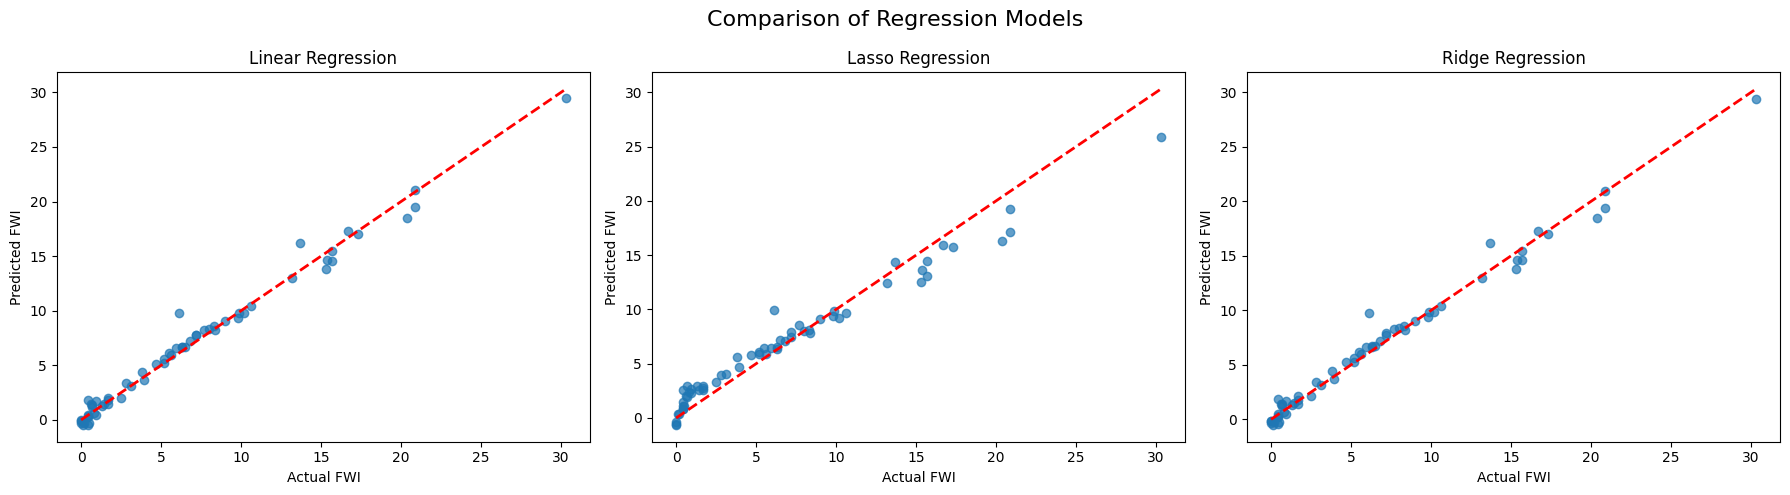

In [42]:
# Predictions
# linear_pred = linreg.predict(X_test_scaled)
# lasso_pred = lasso.predict(X_test_scaled)
ridge_pred = ridge.predict(X_test_scaled)

plt.figure(figsize=(18,5))

# Linear Regression
plt.subplot(1,3,1)
plt.scatter(y_test, linear_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.title("Linear Regression")
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")

# Lasso Regression
plt.subplot(1,3,2)
plt.scatter(y_test, lasso_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.title("Lasso Regression")
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")

# Ridge Regression
plt.subplot(1,3,3)
plt.scatter(y_test, ridge_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.title("Ridge Regression")
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")

plt.suptitle("Comparison of Regression Models", fontsize=16)
plt.tight_layout()
plt.show()

In [43]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Lasso Regression",
        "Ridge Regression"
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, ridge_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred))
    ],
    "R² Score": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, ridge_pred)
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.546824,0.821144,0.984766
1,Lasso Regression,1.133176,1.499449,0.949202
2,Ridge Regression,0.564231,0.833619,0.984299


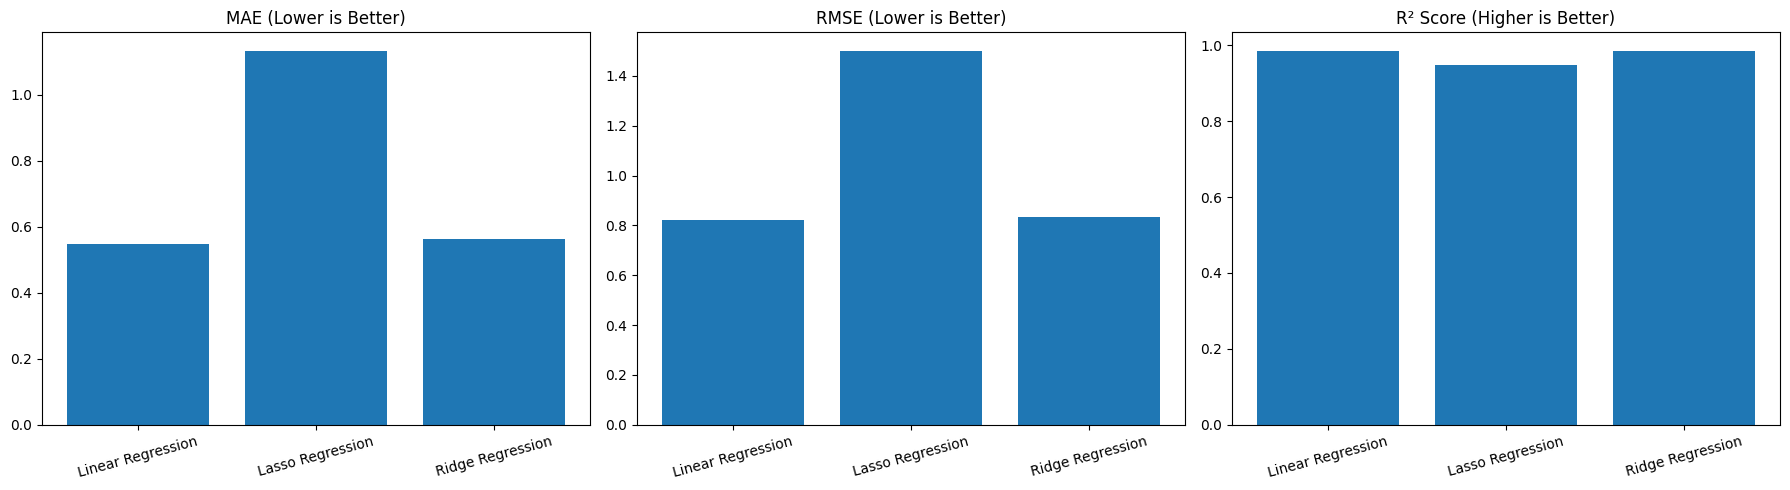

In [44]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

# MAE
axes[0].bar(results["Model"], results["MAE"])
axes[0].set_title("MAE (Lower is Better)")
axes[0].tick_params(axis='x', rotation=15)

# RMSE
axes[1].bar(results["Model"], results["RMSE"])
axes[1].set_title("RMSE (Lower is Better)")
axes[1].tick_params(axis='x', rotation=15)

# R² Score
axes[2].bar(results["Model"], results["R² Score"])
axes[2].set_title("R² Score (Higher is Better)")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## **Train an ElasticNet Regression Model**

**ElasticNet Regression** is a regularized version of Linear Regression that combines the advantages of both:

* **Lasso Regression (L1 Regularization)**
* **Ridge Regression (L2 Regularization)**

Instead of choosing only one type of regularization, ElasticNet uses **both** simultaneously.

As a result, it can:

* Reduce overfitting.
* Handle multicollinearity.
* Perform feature selection.
* Improve model generalization.

In [45]:
from sklearn.linear_model import ElasticNet

# Initialize the ElasticNet Regression model
elastic = ElasticNet()

# Train the model using the training data
elastic.fit(X_train_scaled, y_train)

# Predict the target values for the testing data
elastic_pred = elastic.predict(X_test_scaled)

In [46]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, elastic_pred)
mse = mean_squared_error(y_test, elastic_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, elastic_pred)

print(f"Mean Absolute Error      : {mae:.3f}")
print(f"Mean Squared Error       : {mse:.3f}")
print(f"Root Mean Squared Error  : {rmse:.3f}")
print(f"R² Score                 : {r2:.3f}")

Mean Absolute Error      : 1.882
Mean Squared Error       : 5.517
Root Mean Squared Error  : 2.349
R² Score                 : 0.875


The evaluation metrics measure how accurately the ElasticNet model predicts the Fire Weather Index.

* **Lower MAE** indicates smaller prediction errors.
* **Lower MSE** indicates fewer large errors.
* **Lower RMSE** means the predictions are, on average, closer to the actual values.
* **Higher R² Score** indicates that the model explains a larger proportion of the variation in the target variable.

These metrics can be compared with those of the **Linear Regression**, **Ridge Regression**, and **Lasso Regression** models to determine which model performs best.


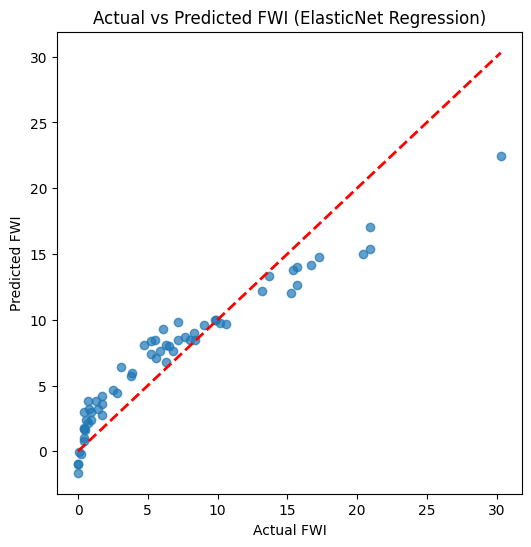

In [47]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, elastic_pred, alpha=0.7)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (ElasticNet Regression)")

plt.show()